In [1]:
import pandas as pd

df = pd.read_csv("data/raw/customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [5]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

In [6]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

In [7]:
df.groupby(["Contract", "Churn"]).size()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
dtype: int64

In [8]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [9]:
pd.crosstab(df["InternetService"], df["Churn"], normalize="index") * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [10]:
df.groupby("Contract")["Churn"].apply(lambda x: (x == "Yes").mean() * 100)

Contract
Month-to-month    42.709677
One year          11.269518
Two year           2.831858
Name: Churn, dtype: float64

Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='Contract'>

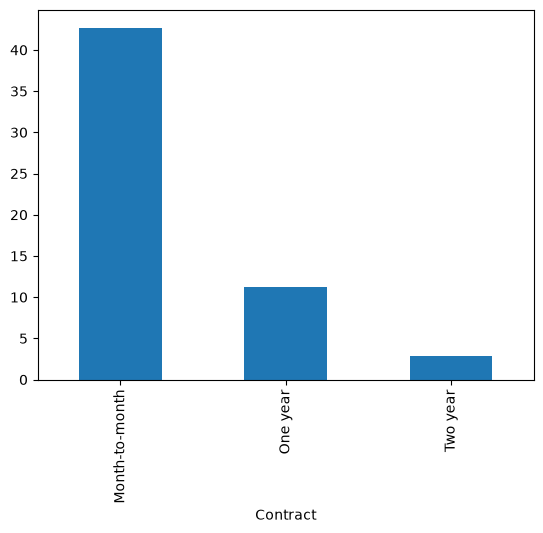

In [11]:
taxa_churn = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
)

taxa_churn.plot(kind="bar")

In [12]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [15]:
df.loc[df["TotalCharges"].isna(), "TotalCharges"] = 0

In [16]:
df[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [17]:
for coluna in df.select_dtypes(include="str").columns:
    print(coluna, ":", df[coluna].nunique())


customerID : 7043
gender : 2
Partner : 2
Dependents : 2
PhoneService : 2
MultipleLines : 3
InternetService : 3
OnlineSecurity : 3
OnlineBackup : 3
DeviceProtection : 3
TechSupport : 3
StreamingTV : 3
StreamingMovies : 3
Contract : 3
PaperlessBilling : 2
PaymentMethod : 4
Churn : 2


In [18]:
X = df.drop(columns=["customerID", "Churn"])
y = df["Churn"]

In [19]:
print(X.shape)
print(y.shape)

(7043, 19)
(7043,)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [22]:
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

In [23]:
print(X_train_encoded.shape)
print(X_test_encoded.shape)

(5634, 30)
(1409, 30)


In [24]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train_encoded, y_train)

/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [25]:
previsoes = modelo.predict(X_test_encoded)

In [26]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, previsoes)
accuracy

0.8034066713981547

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1035
         Yes       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.80      0.80      1409



In [28]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, previsoes)

array([[924, 111],
       [166, 208]])

In [29]:
probabilidades = modelo.predict_proba(X_test_encoded)[:, 1]

In [30]:
previsoes_40 = (probabilidades >= 0.40)

In [31]:
print(classification_report(y_test, previsoes_40))

ValueError: Mix of label input types (string and number); Got ['No' 'Yes'] and [False  True].

In [32]:
previsoes_40 = (probabilidades >= 0.40)
previsoes_40 = ["Yes" if p else "No" for p in previsoes_40]

In [33]:
print(previsoes_40[:10])

['No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'No', 'No']


In [34]:
print(classification_report(y_test, previsoes_40))

              precision    recall  f1-score   support

          No       0.87      0.82      0.85      1035
         Yes       0.57      0.67      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [35]:
confusion_matrix(y_test, previsoes_40)

array([[848, 187],
       [124, 250]])

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    preds = ["Yes" if p >= threshold else "No" for p in probabilidades]

    precision = precision_score(y_test, preds, pos_label="Yes")
    recall = recall_score(y_test, preds, pos_label="Yes")
    f1 = f1_score(y_test, preds, pos_label="Yes")
    accuracy = accuracy_score(y_test, preds)

    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f} | "
        f"Accuracy: {accuracy:.2f}"
    )

Threshold: 0.3 | Precision: 0.52 | Recall: 0.75 | F1: 0.62 | Accuracy: 0.75
Threshold: 0.4 | Precision: 0.57 | Recall: 0.67 | F1: 0.62 | Accuracy: 0.78
Threshold: 0.5 | Precision: 0.65 | Recall: 0.56 | F1: 0.60 | Accuracy: 0.80
Threshold: 0.6 | Precision: 0.72 | Recall: 0.40 | F1: 0.52 | Accuracy: 0.80
Threshold: 0.7 | Precision: 0.73 | Recall: 0.18 | F1: 0.29 | Accuracy: 0.77


In [37]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    probabilidades
)

roc_auc

0.8427032473068278

In [38]:
import pandas as pd

coeficientes = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Coeficiente": modelo.coef_[0]
})

coeficientes = coeficientes.sort_values(
    by="Coeficiente",
    ascending=False
)

coeficientes.head(10)

,Feature,Coeficiente
10,InternetService_Fiber optic,0.745286
28,PaymentMethod_Electronic check,0.396456
26,PaperlessBilling_Yes,0.379109
9,MultipleLines_Yes,0.276635
21,StreamingTV_Yes,0.197491
23,StreamingMovies_Yes,0.194422
8,MultipleLines_No phone service,0.157319
0,SeniorCitizen,0.150306
29,PaymentMethod_Mailed check,0.066728
4,gender_Male,0.022478


In [39]:
coeficientes.tail(10)

,Feature,Coeficiente
18,TechSupport_No internet service,-0.107809
20,StreamingTV_No internet service,-0.107809
22,StreamingMovies_No internet service,-0.107809
15,OnlineBackup_Yes,-0.187043
6,Dependents_Yes,-0.224820
19,TechSupport_Yes,-0.379159
13,OnlineSecurity_Yes,-0.428872
7,PhoneService_Yes,-0.439867
24,Contract_One year,-0.688062
25,Contract_Two year,-1.351580


In [40]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

random_forest.fit(X_train_encoded, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [41]:
rf_probabilidades = random_forest.predict_proba(X_test_encoded)[:, 1]

rf_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    rf_probabilidades
)

rf_auc

0.8266746751401483

In [42]:
rf_previsoes_40 = [
    "Yes" if p >= 0.40 else "No"
    for p in rf_probabilidades
]

print(classification_report(y_test, rf_previsoes_40))

              precision    recall  f1-score   support

          No       0.86      0.83      0.85      1035
         Yes       0.58      0.63      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.79      0.78      0.78      1409



In [43]:
confusion_matrix(y_test, rf_previsoes_40)

array([[862, 173],
       [138, 236]])

In [44]:
from sklearn.model_selection import cross_val_score

X_encoded = pd.get_dummies(X, drop_first=True)

cv_scores = cross_val_score(
    LogisticRegression(max_iter=3000),
    X_encoded,
    y,
    cv=5,
    scoring="roc_auc"
)

cv_scores

/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 3000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=3000).
You might also want to scale the data as

array([0.85823969, 0.85852902, 0.83310729, 0.83829765, 0.83892055])

In [45]:
print("ROC-AUC médio:", cv_scores.mean())
print("Desvio padrão:", cv_scores.std())

ROC-AUC médio: 0.8454188402469566
Desvio padrão: 0.010777424673608328


In [46]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

colunas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
colunas_categoricas = X.select_dtypes(include=["str"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas)
    ]
)

pipeline_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("modelo", LogisticRegression(max_iter=1000))
    ]
)

In [47]:
cv_pipeline = cross_val_score(
    pipeline_logistic,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print(cv_pipeline)
print("ROC-AUC médio:", cv_pipeline.mean())
print("Desvio padrão:", cv_pipeline.std())

[0.85818543 0.85855486 0.83311762 0.83812669 0.83885849]
ROC-AUC médio: 0.8453686192882485
Desvio padrão: 0.010798721219487517


In [48]:
pipeline_logistic.fit(X_train, y_train)

probabilidades_pipeline = pipeline_logistic.predict_proba(X_test)[:, 1]

In [49]:
previsoes_pipeline_40 = [
    "Yes" if p >= 0.40 else "No"
    for p in probabilidades_pipeline
]

In [50]:
print(classification_report(y_test, previsoes_pipeline_40))

              precision    recall  f1-score   support

          No       0.87      0.82      0.84      1035
         Yes       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [51]:
print(confusion_matrix(y_test, previsoes_pipeline_40))

roc_auc_pipeline = roc_auc_score(
    (y_test == "Yes").astype(int),
    probabilidades_pipeline
)

print("ROC-AUC:", roc_auc_pipeline)

[[845 190]
 [124 250]]
ROC-AUC: 0.8421349040274871


In [52]:
import numpy as np

resultados_threshold = []

for threshold in np.arange(0.1, 0.91, 0.01):
    preds = [
        "Yes" if p >= threshold else "No"
        for p in probabilidades_pipeline
    ]

    precision = precision_score(y_test, preds, pos_label="Yes")
    recall = recall_score(y_test, preds, pos_label="Yes")
    f1 = f1_score(y_test, preds, pos_label="Yes")

    resultados_threshold.append(
        [threshold, precision, recall, f1]
    )

df_thresholds = pd.DataFrame(
    resultados_threshold,
    columns=["Threshold", "Precision", "Recall", "F1"]
)

df_thresholds.sort_values("F1", ascending=False).head(10)

/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/franciscosilva/ai-portfolio/customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _

,Threshold,Precision,Recall,F1
17,0.27,0.514938,0.783422,0.621421
18,0.28,0.516874,0.778075,0.621131
16,0.26,0.506780,0.799465,0.620332
21,0.31,0.529301,0.748663,0.620155
29,0.39,0.566964,0.679144,0.618005
28,0.38,0.559913,0.687166,0.617047
15,0.25,0.497537,0.810160,0.616480
19,0.29,0.516245,0.764706,0.616379
27,0.37,0.554604,0.692513,0.615933
23,0.33,0.538000,0.719251,0.615561


In [53]:
from sklearn.metrics import average_precision_score

average_precision = average_precision_score(
    (y_test == "Yes").astype(int),
    probabilidades_pipeline
)

print("Average Precision:", average_precision)

Average Precision: 0.6343385058492537


In [54]:
threshold_max_f1 = 0.27
threshold_negocio = 0.39

In [55]:
for threshold in [0.27, 0.39]:
    preds = [
        "Yes" if p >= threshold else "No"
        for p in probabilidades_pipeline
    ]

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_test, preds))
    print(confusion_matrix(y_test, preds))


Threshold: 0.27
              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1035
         Yes       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409

[[759 276]
 [ 81 293]]

Threshold: 0.39
              precision    recall  f1-score   support

          No       0.88      0.81      0.84      1035
         Yes       0.57      0.68      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.79      0.78      0.78      1409

[[841 194]
 [120 254]]


In [56]:
threshold_final = 0.39

In [57]:
pipeline_final = pipeline_logistic

pipeline_final.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``rema

In [58]:
import joblib

In [59]:
joblib.dump(pipeline_final, "churn_model.joblib")

['churn_model.joblib']

In [60]:
joblib.dump(threshold_final, "churn_threshold.joblib")

['churn_threshold.joblib']

In [61]:
novo_cliente = pd.DataFrame([{
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0
}])

In [62]:
probabilidade_churn = pipeline_final.predict_proba(novo_cliente)[0, 1]

print("Probabilidade de churn:", probabilidade_churn)

Probabilidade de churn: 0.7660513488537483


In [63]:
probabilidade_churn = pipeline_final.predict_proba(novo_cliente)[0, 1]

print("Probabilidade de churn:", probabilidade_churn)

Probabilidade de churn: 0.7660513488537483


In [64]:
if probabilidade_churn >= threshold_final:
    print("Cliente em risco de churn")
else:
    print("Cliente com baixo risco de churn")

Cliente em risco de churn


In [65]:
def prever_churn(cliente):
    dados_cliente = pd.DataFrame([cliente])

    probabilidade = pipeline_final.predict_proba(dados_cliente)[0, 1]

    previsao = (
        "Alto risco de churn"
        if probabilidade >= threshold_final
        else "Baixo risco de churn"
    )

    return {
        "probabilidade_churn": probabilidade,
        "previsao": previsao
    }

In [66]:
cliente_teste = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 5,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "Yes",
    "StreamingMovies": "Yes",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 85.0,
    "TotalCharges": 425.0
}

resultado = prever_churn(cliente_teste)
resultado

{'probabilidade_churn': np.float64(0.7660513488537483),
 'previsao': 'Alto risco de churn'}

In [67]:
def prever_churn(cliente):
    dados_cliente = pd.DataFrame([cliente])

    probabilidade = pipeline_final.predict_proba(dados_cliente)[0, 1]
    probabilidade = float(probabilidade)

    previsao = (
        "Alto risco de churn"
        if probabilidade >= threshold_final
        else "Baixo risco de churn"
    )

    return {
        "probabilidade_churn": probabilidade,
        "probabilidade_percentagem": round(probabilidade * 100, 1),
        "previsao": previsao
    }

In [68]:
resultado = prever_churn(cliente_teste)
resultado

{'probabilidade_churn': 0.7660513488537483,
 'probabilidade_percentagem': 76.6,
 'previsao': 'Alto risco de churn'}